In [1]:
import json
from pathlib import Path
import os
import glob
from functools import reduce

from upsetplot import from_contents, plot
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay, auc, roc_auc_score
import matplotlib.pyplot as plt
from upsetplot import from_contents, plot, UpSet
from statsmodels.stats.inter_rater import aggregate_raters, fleiss_kappa

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [13]:
selected_models = [
    "../exps/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T10-31-50A.json",
    "../exps/FSAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T17-02-42A.json",
    "../exps/FSAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T15-42-41A.json",
    "../exps/FSAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T14-11-04A.json",
    "../exps/FRAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T16-35-57A.json",
    "../exps/FRAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T19-54-50A.json",
    "../exps/FRAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T22-36-50A.json",
    "../exps/FRAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T22-08-33A.json",
]

preds_by_model = []
video_list_ff = []
video_list_fr = []
video_labels_ff = []
video_labels_fr = []

clip_preds_ff = []
i3d_preds_ff = []
xception_preds_ff = []
spsl_preds_ff = []

clip_preds_fr = []
i3d_preds_fr = []
xception_preds_fr = []
spsl_preds_fr = []


with open("../exps/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T10-31-50A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            video_list_ff.append(video_path)
            video_labels_ff.append(infos["label"])
            clip_preds_ff.append(infos["pred"])

with open("../exps/FSAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T17-02-42A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            i3d_preds_ff.append(infos["pred"])
    
    
with open("../exps/FSAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T15-42-41A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            xception_preds_ff.append(infos["pred"])

with open("../exps/FSAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T14-11-04A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            spsl_preds_ff.append(infos["pred"])

with open("../exps/FRAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T16-35-57A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            video_list_fr.append(video_path)
            video_labels_fr.append(infos["label"])
            clip_preds_fr.append(infos["pred"])

with open("../exps/FRAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T19-54-50A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            i3d_preds_fr.append(infos["pred"])

with open("../exps/FRAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T22-36-50A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            xception_preds_fr.append(infos["pred"])

with open("../exps/FRAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T22-08-33A.json") as file:
    all_info = json.load(file)
    video_infos = all_info["vids_results"]

    for video_path, infos in video_infos.items():
            spsl_preds_fr.append(infos["pred"])


    

In [ ]:
    
def fixed_tpr(labels, raw_preds, tpr_goal=0.8)      
    fpr, tpr, thresholds = roc_curve(labels, raw_preds)

    idx = np.argmax(tpr >= tpr_goal)

    fpr_at_goal = fpr[idx]
    threshold_at_goal = thresholds[idx]

    return threshold_at_goal
    

In [ ]:
video_list = video_list_ff + video_list_fr
video_labels = video_labels_ff + video_labels_fr

clip_preds = clip_preds_ff + clip_preds_fr
i3d_preds = i3d_preds_ff + i3d_preds_fr
xception_preds_ff = xception_preds_ff + xception_preds_fr
spsl_preds = spsl_preds_ff + spsl_preds_fr

tresh_clip = fixed_tpr(video_labels, clip_preds)
tresh_i3d = fixed_tpr(video_labels, )

In [ ]:
selected_models = [
    "../exps/FSAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T10-31-50A.json",
    "../exps/FSAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T17-02-42A.json",
    "../exps/FSAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T15-42-41A.json",
    "../exps/FSAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T14-11-04A.json",
    "../exps/FRAll_cdf/clip_base/train_on_df40-all-ff/preds/video-level/2026-02-23T16-35-57A.json",
    "../exps/FRAll_cdf/i3d/train_on_df40-all-ff/preds/video-level/2026-02-23T19-54-50A.json",
    "../exps/FRAll_cdf/xception/train_on_df40-all-ff/preds/video-level/2026-02-23T22-36-50A.json",
    "../exps/FRAll_cdf/spsl/train_on_df40-fs-ff/preds/video-level/2026-02-23T22-08-33A.json",
]



for path in selected_models:
    video_list = []
    video_labels = []
    with open(path) as file:
        all_info = json.load(file)
        video_infos = all_info["vids_results"]

        model_name = all_info["model_name"]
        print(model_name)
        train_dataset = all_info["train_dataset"]
        if train_dataset == "train_on_ff-orig":
            train_dataset = "ff-orig"
        elif train_dataset == "train_on_df40-fr-ff":
            train_dataset = "df40-fr-ff"
        elif train_dataset == "train_on_df40-fs-ff":
            train_dataset = "df40-fs-ff"
        elif train_dataset == "train_on_df40-all-ff":
            train_dataset = "df40-all-ff"
        test_dataset = all_info["test_dataset"]

        if test_dataset

        detector_preds = []
        detector_logits = []

        for video_path, infos in video_infos.items():
            video_list.append(video_path)
            video_labels.append(infos["label"])

            detector_preds.append(infos["pred"])
            #detector_logits.append(infos["logit"])

        print(len(detector_preds))

        detector_preds = pd.Series(detector_preds)

        fpr, tpr, thresholds = roc_curve(video_labels, detector_preds)

        target_tpr = 0.8

        idx = np.argmax(tpr >= target_tpr)

        fpr_at_goal = fpr[idx]
        threshold_at_goal = thresholds[idx]

        detector_choices = []

        print(len(detector_preds))

        for p in detector_preds:
            if p >= threshold_at_goal:
                detector_choices.append(1)
            else:
                detector_choices.append(0)

    df_export = pd.DataFrame()
    df_export["video_path"] = video_list
    df_export["label"] = video_labels
    df_export["pred"] = pd.Series(detector_preds)
    df_export["choice"] = pd.Series(detector_choices)
    #df_export[f"logit_{model_name}#{train_dataset}"] = detector_logits

    df_export.to_csv(f"results/results-{model_name}.csv", mode="a")
            

clip_base
5339
5339
i3d
4866
4866
xception
5339
5339
spsl
5339
5339
clip_base
7948
7948
i3d
6544
6544
xception
7948
7948
spsl
7948
7948


In [7]:
csvs = []

for file in os.scandir("results"):
    csvs.append(file)


dataframes = []

for i, file in enumerate(csvs):
    df = pd.read_csv(file)
    
    if i == 0:
        df_propre = df[['video_path', 'label', 'choice']].copy()
    else:
        df_propre = df[['video_path', 'choice']].copy()
        
    df_propre = df_propre.rename(columns={'choice': f'{file.name}'})
    
    dataframes.append(df_propre)

df_finale = reduce(lambda left, right: pd.merge(left, right, on='video_path', how='outer'), dataframes)

In [8]:
errors_by_detec = {}
errors_by_detec_bin = {}

for index, row in df_finale.iterrows():
    video_path = None
    name = None
    label = None
    for col in row.items():
        if col[0] == "video_path":
            video_path = col[1]
        elif col[0] == "label":
            label = col[1]
            continue
        else:
            if col[1] != label:
                if col[0] in errors_by_detec.keys():
                    if pd.isna(col[1]):
                        errors_by_detec[col[0]].append(video_path)
                        errors_by_detec_bin[col[0]].append(1)
                    else:
                        errors_by_detec[col[0]].append(video_path)
                        errors_by_detec_bin[col[0]].append(1)
                else:
                    errors_by_detec[col[0]] = [video_path]
                    errors_by_detec_bin[col[0]] = [1]

            else:
                if col[0] in errors_by_detec.keys():
                    errors_by_detec_bin[col[0]].append(0)
                else:
                    errors_by_detec_bin[col[0]] = [0]

/home/antoine/miniconda3/envs/df40/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/antoine/miniconda3/envs/df40/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["lin

<Figure size 1500x800 with 0 Axes>

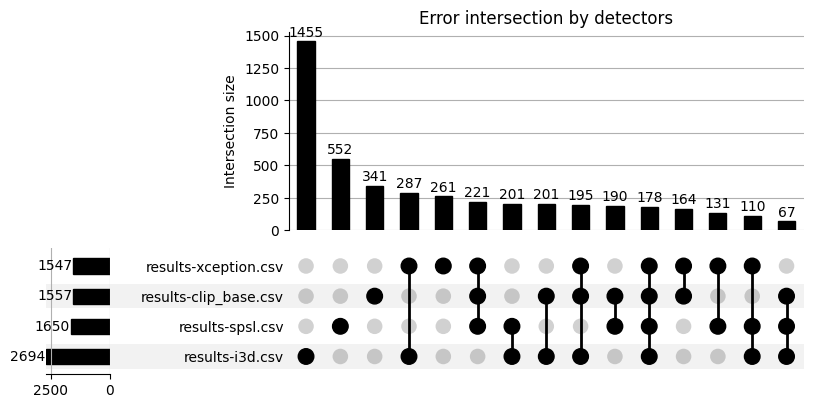

In [9]:
data_for_upset = from_contents(errors_by_detec)

plt.figure(figsize=(15, 8))
plot(data_for_upset, show_counts=True, sort_by="cardinality")
plt.title("Error intersection by detectors")
plt.show()